# Data & Methods (Prototype)

This notebook provides an overview of the data sources and analytical methods that will be used in the full extreme-weather project.  
All datasets shown below are **synthetic placeholders**, allowing the analysis workflow to be developed before integrating real meteorological data (ERA5, GFS, satellite imagery, and surface station observations).

The main goals of this notebook are:

- Demonstrate the structure of each data source
- Show example preprocessing steps
- Provide simple visualizations using synthetic datasets
- Establish a methodological foundation for the upcoming group project


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. ERA5 Reanalysis (Synthetic Example)

In the final project, ERA5 will be used for:
- 3D temperature fields
- Wind speed and direction
- Vertical profiles and stability diagnostics
- Precipitation and snowfall (lake-effect case)

Below is a *synthetic* 3D temperature field representing:
- latitude × longitude × pressure-level


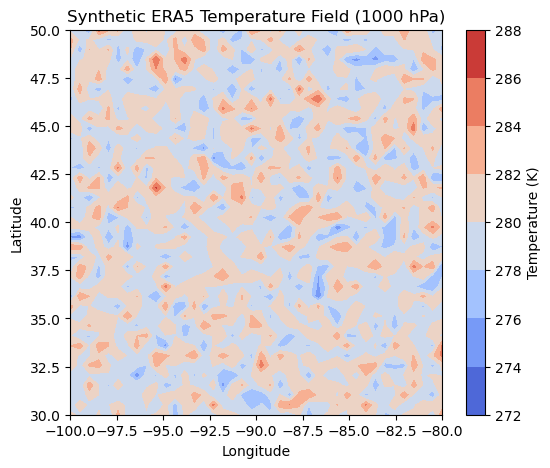

In [2]:
lats = np.linspace(30, 50, 40)       # 40 grid points
lons = np.linspace(-100, -80, 40)
levels = np.array([1000, 850, 700, 500])  # hPa

# create synthetic 3D temperature field (K)
T = 280 - 0.006*(lats[:,None,None]) + 2*np.random.randn(40,40,4)

# plot one level
plt.figure(figsize=(6,5))
plt.contourf(lons, lats, T[:,:,0], cmap="coolwarm")
plt.title("Synthetic ERA5 Temperature Field (1000 hPa)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label="Temperature (K)")
plt.show()

## 2. GFS Forecast Model Output (Synthetic Example)

The GFS model will be used to evaluate forecast skill.  
The real project will compare:

**GFS forecast − ERA5 reanalysis**

for variables such as:
- temperature
- wind speed
- precipitation

Below is a synthetic GFS temperature forecast at +24 hours.


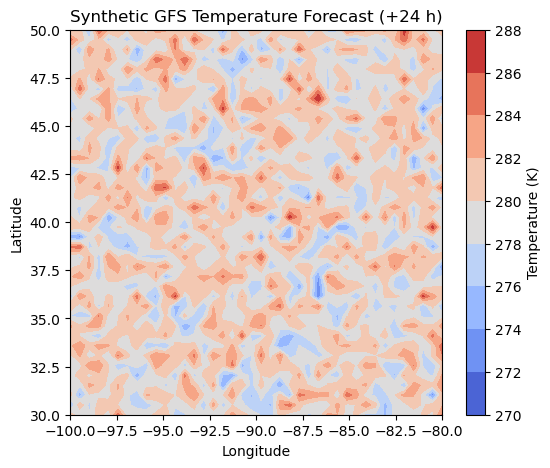

In [3]:
GFS_T = T[:,:,0] + 1.5*np.random.randn(40,40)   # add error

plt.figure(figsize=(6,5))
plt.contourf(lons, lats, GFS_T, cmap="coolwarm")
plt.title("Synthetic GFS Temperature Forecast (+24 h)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label="Temperature (K)")
plt.show()

## 3. Model Verification Example (Synthetic)

A key component of the full project will be quantifying how far the model deviates from reality.

We demonstrate this by computing the synthetic difference:

**Error = GFS forecast − ERA5 reanalysis**


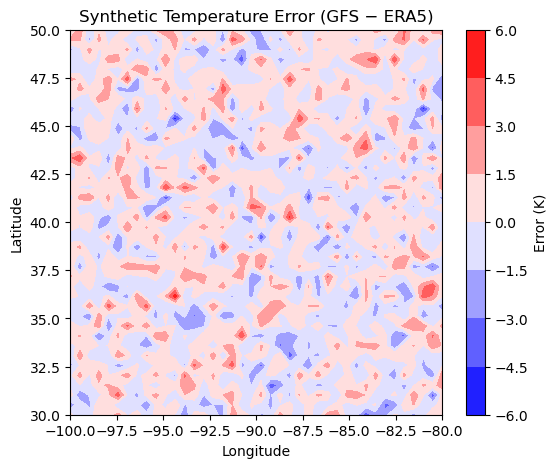

In [4]:
diff = GFS_T - T[:,:,0]

plt.figure(figsize=(6,5))
plt.contourf(lons, lats, diff, cmap="bwr")
plt.title("Synthetic Temperature Error (GFS − ERA5)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label="Error (K)")
plt.show()

## 4. Satellite Imagery (Synthetic)

Satellite imagery (GOES IR/Visible) will be included for each event.  
Below is a synthetic “cloud-top brightness temperature” field.


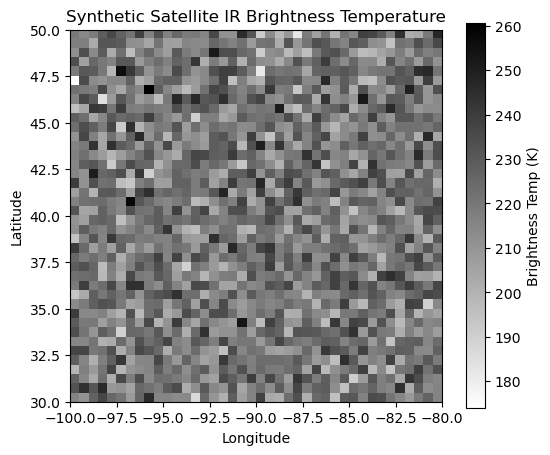

In [5]:
cloud = 220 + 12*np.random.randn(40,40)  # colder = higher cloud tops

plt.figure(figsize=(6,5))
plt.imshow(cloud, cmap="gray_r", extent=[lons.min(), lons.max(), lats.min(), lats.max()])
plt.title("Synthetic Satellite IR Brightness Temperature")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label="Brightness Temp (K)")
plt.show()

## 5. Surface Station Observations (Synthetic)

Surface observations from ASOS stations (temperature, wind, pressure)  
will be used for:

- model validation
- time series analysis
- near-surface impacts

Below is a synthetic example with 12 stations.


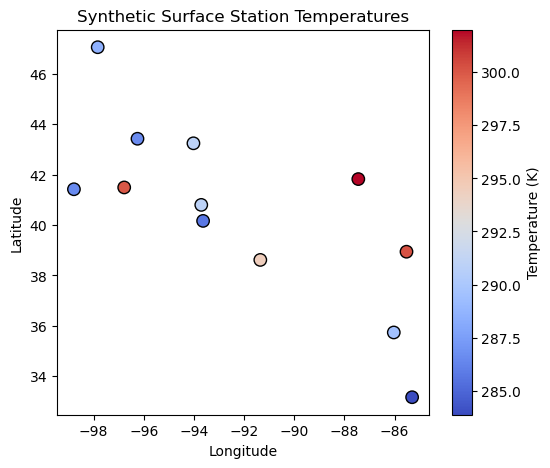

In [6]:
station_lats = np.random.uniform(32, 48, 12)
station_lons = np.random.uniform(-99, -82, 12)
station_temp = 290 + 5*np.random.randn(12)

plt.figure(figsize=(6,5))
plt.scatter(station_lons, station_lats, c=station_temp, cmap="coolwarm", s=80, edgecolor="k")
plt.title("Synthetic Surface Station Temperatures")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label="Temperature (K)")
plt.show()

## Summary

This notebook established the prototype workflow for the **Data & Methods** section:

- Synthetic versions of ERA5, GFS, satellite data, and surface stations  
- Example visualizations for each dataset  
- Demonstration of model-verification methods

In the final group project, these synthetic datasets will be replaced with real meteorological data and expanded analyses.